# KVCascade — wikitext-103 evaluation

Three experiments comparing KV cache strategies on wikitext-103 with teacher-forced sequential decode:

1. **Compression sweep**: how few bytes does KVCascade need to match uniform TurboQuant?
2. **Iso-byte head-to-head**: at the same byte budget, who wins (full-fp / uniform / H2O / KVCascade)?
3. **Split sweep**: within KVCascade at fixed budget, what's the optimal ring/fp/quant allocation?

Plus an attention-pattern visualization on the test sample to ground intuition about peaky vs diffuse attention for the model under test.

**Methodology**: prefill `(ctx_len - decode_len)` tokens, run `decode_len` sequential 1-token forwards using the cache, compare each step's argmax against the fp reference's argmax at the same position. Top-1 = "fraction of decode positions where the cache config and fp reference agree." Teacher-forced — at each step we feed the ground-truth token from the original sequence, not the model's prediction.

All cache configs share: TurboQuant for quantized tiers (`k_bits=6`, `v_bits=2`, `m=D`), `score_policy="ema"` for KVCascade and `"cumulative"` for H2O, single quant tier across all KVCascade configs.

## Configuration

Edit these to swap models / sample counts / context lengths. Everything below adapts.

In [1]:
MODEL_NAME    = "Qwen/Qwen3-0.6B"
N_SAMPLES     = 20
CTX_LEN       = 4096
DECODE_LEN    = 64
SEED          = 42
DEVICE        = "cuda"
DTYPE_NAME    = "bfloat16"

# Smaller context for the attention-pattern viz pass so the [L, H, T, T] attention
# matrices fit in VRAM. 1024 tokens is plenty for visualizing diffuse-vs-peaky
# structure; the eval itself still uses CTX_LEN.
VIZ_CTX_LEN = 1024

# Quant tier defaults (single tier across all KVCascade configs).
K_BITS = 6
V_BITS = 2

## Setup

In [2]:
import os, sys
_REPO = os.path.dirname(os.path.dirname(os.path.abspath("notebooks/wikitext_eval.ipynb")))
if not os.path.isdir(os.path.join(_REPO, "src")):
    _REPO = os.path.abspath("..")  # fallback when CWD differs
sys.path.insert(0, os.path.join(_REPO, "src"))

import gc
import math
import statistics

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from kvcascade import KVCascadeCache, install_kvcascade, make_h2o_cache
from turbo_attn import TurboQuantKVCache, install_turbo_attention, _force_set_attn_impl

DEVICE_T = torch.device(DEVICE)
DTYPE = {"float32": torch.float32, "float16": torch.float16, "bfloat16": torch.bfloat16}[DTYPE_NAME]
torch.manual_seed(SEED)
print(f"torch={torch.__version__}, device={DEVICE_T}, dtype={DTYPE}")

/venv/kvcascade/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch=2.11.0+cu130, device=cuda, dtype=torch.bfloat16


In [3]:
print(f"loading {MODEL_NAME}...")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, attn_implementation="eager",
).to(DEVICE_T).eval()

cfg = model.config
N_LAYERS   = cfg.num_hidden_layers
N_HEADS    = cfg.num_attention_heads
N_KV_HEADS = getattr(cfg, "num_key_value_heads", N_HEADS)
HEAD_DIM   = getattr(cfg, "head_dim", None) or (cfg.hidden_size // N_HEADS)
print(f"L={N_LAYERS}  H_q={N_HEADS}  H_kv={N_KV_HEADS}  D={HEAD_DIM}")

loading Qwen/Qwen3-0.6B...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 6119.85it/s]


L=28  H_q=16  H_kv=8  D=128


In [4]:
def get_samples(tok, n_samples, ctx_len):
    ds = load_dataset("wikitext", "wikitext-103-v1", split="test", streaming=True)
    chunks, total_chars = [], 0
    target_chars = n_samples * ctx_len * 6
    for item in ds:
        if item["text"].strip():
            chunks.append(item["text"])
            total_chars += len(item["text"])
            if total_chars >= target_chars:
                break
    big_text = "".join(chunks)
    all_ids = tok(big_text, return_tensors="pt").input_ids[0]
    out = []
    for i in range(n_samples):
        s, e = i * ctx_len, (i + 1) * ctx_len
        if e > len(all_ids):
            print(f"  warning: only {i}/{n_samples} samples available")
            break
        out.append(all_ids[s:e].unsqueeze(0))
    return out

samples = get_samples(tok, N_SAMPLES, CTX_LEN)
T_PRE = CTX_LEN - DECODE_LEN
print(f"loaded {len(samples)} samples; T_pre={T_PRE}, T_dec={DECODE_LEN}")

loaded 20 samples; T_pre=4032, T_dec=64


In [5]:
def set_attn_impl(model, value):
    _force_set_attn_impl(model.config, value)
    for sub in model.modules():
        if hasattr(sub, "config") and sub is not model:
            _force_set_attn_impl(sub.config, value)

print("computing fp reference logits (one forward per sample)...")
set_attn_impl(model, "eager")
ref_decs = []
with torch.no_grad():
    for ids in samples:
        ids_d = ids.to(DEVICE_T)
        logits = model(input_ids=ids_d, use_cache=False).logits
        ref_decs.append(logits[:, T_PRE:T_PRE + DECODE_LEN, :].float().cpu())
        del logits
torch.cuda.empty_cache()
print(f"fp reference: {len(ref_decs)} samples")

computing fp reference logits (one forward per sample)...
fp reference: 20 samples


## Attention pattern visualization

Run a fp forward pass on the first `VIZ_CTX_LEN` tokens of sample 0 (default 1024 — large enough to see the patterns, small enough to avoid OOM on the attention stack) and visualize:

1. Heatmap of attention-received-per-token across heads, for representative layers.
2. Histogram of per-(layer, head) attention entropy (lower = peakier).
3. Detail views of the most peaky and most diffuse heads.

We use a custom attention dispatcher that extracts summary stats per layer and discards the full `[H, T, T]` matrix before the next layer runs (peak ≈ one layer at a time, ~33 MB at T=1024) — naively setting `output_attentions=True` at the eval's CTX_LEN=4096 would need ~15 GB of VRAM for the stacked attentions.

This grounds intuition about whether eviction-based caches are even theoretically viable for this model+context. Peaky attention → small set of "load-bearing" tokens → KVCascade should win cleanly. Diffuse → most tokens carry softmax mass → quantization-only (uniform) might be safer.

In [6]:
# Avoid OOM on the [L, H, T, T] attention stack: install a custom attention dispatcher
# that extracts per-(L, H) summary stats inline and DISCARDS each layer's full matrix
# before the next layer runs. Peak memory stays at ~one layer's worth (33 MB at T=1024
# vs. 15 GB if we naively used output_attentions=True at T=4096).
from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS

ids_viz = samples[0][:, :VIZ_CTX_LEN].to(DEVICE_T)
print(f"viz forward on first {VIZ_CTX_LEN} tokens of sample 0")

entropies_cpu = torch.zeros(N_LAYERS, N_HEADS)
received_cpu  = torch.zeros(N_LAYERS, N_HEADS, VIZ_CTX_LEN)

def _viz_stats_attn(module, query, key, value, attention_mask=None,
                     scaling=None, dropout=0.0, **kwargs):
    if scaling is None:
        scaling = 1.0 / math.sqrt(query.shape[-1])
    n_rep = query.shape[1] // key.shape[1]
    k_e = key.repeat_interleave(n_rep, dim=1) if n_rep > 1 else key
    v_e = value.repeat_interleave(n_rep, dim=1) if n_rep > 1 else value
    scores = torch.matmul(query, k_e.transpose(-1, -2)) * scaling
    if attention_mask is not None:
        scores = scores + attention_mask[..., :scores.shape[-1]]
    attn = torch.softmax(scores, dim=-1, dtype=torch.float32).to(query.dtype)
    out = torch.matmul(attn, v_e).transpose(1, 2).contiguous()

    layer_idx = module.layer_idx
    a32 = attn.float()
    a32_safe = a32.clamp_min(1e-12)
    entropies_cpu[layer_idx] = (-(a32_safe * a32_safe.log()).sum(dim=-1)).mean(dim=(0, 2)).cpu()
    received_cpu[layer_idx]  = a32.sum(dim=2).squeeze(0).cpu()
    # Return None for attn weights so HF doesn't accumulate them in outputs.attentions.
    return out, None

ALL_ATTENTION_FUNCTIONS["__kvc_viz_stats__"] = _viz_stats_attn
set_attn_impl(model, "__kvc_viz_stats__")
with torch.no_grad():
    model(input_ids=ids_viz, use_cache=False)
set_attn_impl(model, "eager")
torch.cuda.empty_cache()

entropies = entropies_cpu.numpy()
print(f"entropy grid: shape {entropies.shape}, range [{entropies.min():.2f}, {entropies.max():.2f}]")

viz forward on first 1024 tokens of sample 0
entropy grid: shape (28, 16), range [0.33, 6.90]


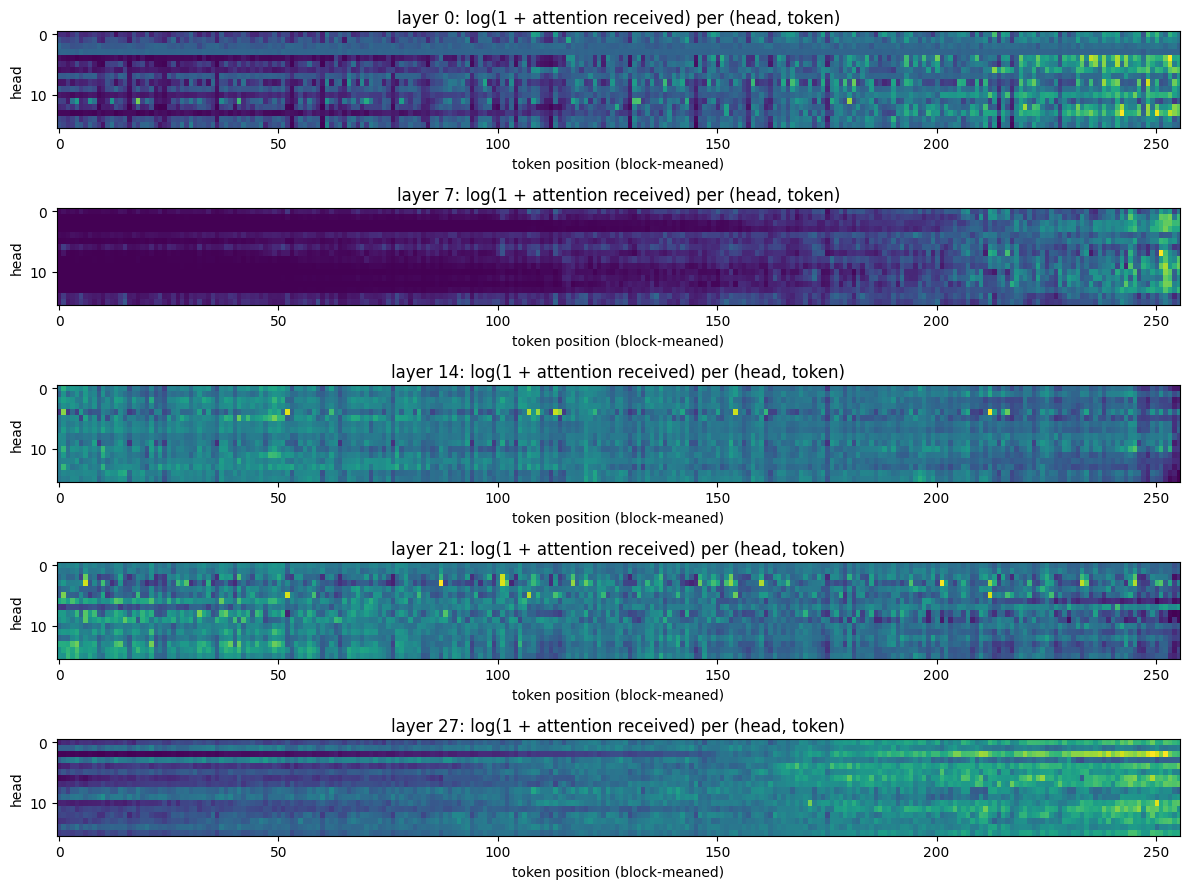

In [7]:
# Per-(head, token) attention received, for a few representative layers.
select_layers = sorted(set([0, N_LAYERS // 4, N_LAYERS // 2, 3 * N_LAYERS // 4, N_LAYERS - 1]))
fig, axes = plt.subplots(len(select_layers), 1, figsize=(12, 1.8 * len(select_layers)),
                          squeeze=False)
for ax, l in zip(axes[:, 0], select_layers):
    rec = received_cpu[l].numpy()  # [H, VIZ_CTX_LEN]
    BLOCK = max(1, rec.shape[1] // 256)
    if BLOCK > 1:
        T_k = rec.shape[1]
        rec = rec[:, : T_k - T_k % BLOCK].reshape(rec.shape[0], -1, BLOCK).mean(-1)
    im = ax.imshow(np.log1p(rec), aspect="auto", cmap="viridis")
    ax.set_title(f"layer {l}: log(1 + attention received) per (head, token)")
    ax.set_xlabel("token position (block-meaned)"); ax.set_ylabel("head")
plt.tight_layout(); plt.show()

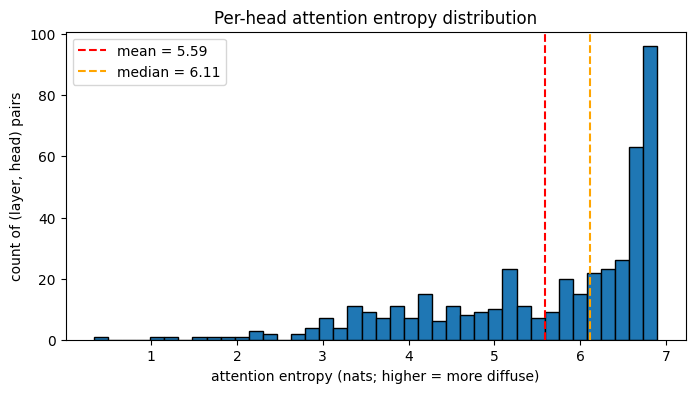

theoretical max entropy for uniform over T=1024: 6.93 nats
empirical: mean=5.59, fraction = 80.71% of uniform


In [8]:
# Entropy histogram across all (layer, head) pairs.
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(entropies.flatten(), bins=40, edgecolor="k")
mean_e, med_e = entropies.mean(), float(np.median(entropies))
ax.axvline(mean_e, color="red",    ls="--", label=f"mean = {mean_e:.2f}")
ax.axvline(med_e,  color="orange", ls="--", label=f"median = {med_e:.2f}")
ax.set_xlabel("attention entropy (nats; higher = more diffuse)")
ax.set_ylabel("count of (layer, head) pairs")
ax.set_title("Per-head attention entropy distribution")
ax.legend(); plt.show()

# Theoretical max entropy for fully-uniform attention over VIZ_CTX_LEN keys.
max_ent = math.log(VIZ_CTX_LEN)
print(f"theoretical max entropy for uniform over T={VIZ_CTX_LEN}: {max_ent:.2f} nats")
print(f"empirical: mean={mean_e:.2f}, fraction = {mean_e/max_ent:.2%} of uniform")

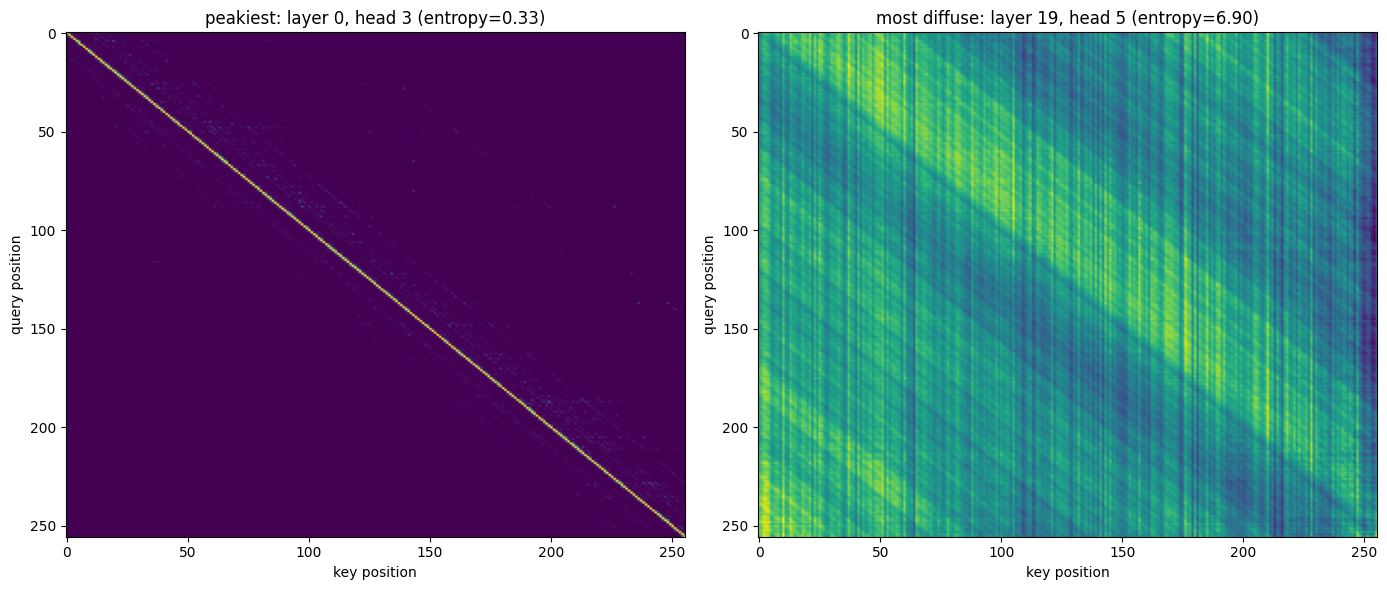

In [9]:
# Detail views: most peaky and most diffuse head. Run a second pass that ALSO captures
# the full attention matrix for the two target layers (~33 MB each at T=1024 — fine).
flat = entropies.flatten()
peaky_l, peaky_h     = divmod(int(flat.argmin()), N_HEADS)
diffuse_l, diffuse_h = divmod(int(flat.argmax()), N_HEADS)
target_layers = {peaky_l, diffuse_l}
detail_attn = {}  # layer_idx -> [H, T, T] cpu fp32

def _viz_detail_attn(module, query, key, value, attention_mask=None,
                      scaling=None, dropout=0.0, **kwargs):
    if scaling is None:
        scaling = 1.0 / math.sqrt(query.shape[-1])
    n_rep = query.shape[1] // key.shape[1]
    k_e = key.repeat_interleave(n_rep, dim=1) if n_rep > 1 else key
    v_e = value.repeat_interleave(n_rep, dim=1) if n_rep > 1 else value
    scores = torch.matmul(query, k_e.transpose(-1, -2)) * scaling
    if attention_mask is not None:
        scores = scores + attention_mask[..., :scores.shape[-1]]
    attn = torch.softmax(scores, dim=-1, dtype=torch.float32).to(query.dtype)
    out = torch.matmul(attn, v_e).transpose(1, 2).contiguous()
    if module.layer_idx in target_layers:
        detail_attn[module.layer_idx] = attn.squeeze(0).float().cpu()
    return out, None

ALL_ATTENTION_FUNCTIONS["__kvc_viz_detail__"] = _viz_detail_attn
set_attn_impl(model, "__kvc_viz_detail__")
with torch.no_grad():
    model(input_ids=ids_viz, use_cache=False)
set_attn_impl(model, "eager")
torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (l, h, lbl) in zip(axes,
        [(peaky_l, peaky_h, "peakiest"), (diffuse_l, diffuse_h, "most diffuse")]):
    a = detail_attn[l][h].numpy()  # [T, T] fp32 on cpu
    BLOCK = max(1, a.shape[0] // 256)
    if BLOCK > 1:
        T = a.shape[0] // BLOCK * BLOCK
        a = a[:T, :T].reshape(T // BLOCK, BLOCK, T // BLOCK, BLOCK).mean(axis=(1, 3))
    im = ax.imshow(np.log1p(a * 1000), aspect="auto", cmap="viridis")
    ax.set_title(f"{lbl}: layer {l}, head {h} (entropy={entropies[l, h]:.2f})")
    ax.set_xlabel("key position"); ax.set_ylabel("query position")
plt.tight_layout(); plt.show()

del detail_attn; gc.collect(); torch.cuda.empty_cache()

## Cache evaluation helpers

In [10]:
def fp_slot_bytes():
    return 2 * HEAD_DIM * torch.empty((), dtype=DTYPE).element_size()

def turbo_slot_bytes(k_bits=K_BITS, v_bits=V_BITS, m=None):
    if m is None: m = HEAD_DIM
    fp = torch.empty((), dtype=DTYPE).element_size()
    return (3 * fp                                    # k_norm, k_resnorm, v_norm
            + (HEAD_DIM * (k_bits - 1) + 7) // 8       # k_idx_packed
            + (HEAD_DIM * v_bits + 7) // 8             # v_idx_packed
            + (m + 7) // 8)                            # k_ressign_packed (1 bit per m)

UNIFORM_BYTES_PER_LH = CTX_LEN * turbo_slot_bytes()
FP16_BASELINE_PER_LH  = CTX_LEN * fp_slot_bytes()
print(f"fp slot      = {fp_slot_bytes()} B")
print(f"turbo slot   = {turbo_slot_bytes()} B")
print(f"uniform iso-byte target  per (L, H_kv) = {UNIFORM_BYTES_PER_LH:>8} B")
print(f"full-fp baseline         per (L, H_kv) = {FP16_BASELINE_PER_LH:>8} B")
print(f"uniform compression vs fp: {FP16_BASELINE_PER_LH / UNIFORM_BYTES_PER_LH:.2f}x")

def make_uniform():
    return TurboQuantKVCache(
        num_layers=N_LAYERS, batch_size=1,
        num_heads=N_HEADS, num_kv_heads=N_KV_HEADS,
        head_dim=HEAD_DIM, max_seq_len=CTX_LEN,
        k_bits=K_BITS, v_bits=V_BITS, m=HEAD_DIM,
        seed=SEED, device=DEVICE_T, dtype=DTYPE,
    )

def make_h2o(cache_size, recency_window=0):
    return make_h2o_cache(
        num_layers=N_LAYERS, batch_size=1,
        num_heads=N_HEADS, num_kv_heads=N_KV_HEADS,
        head_dim=HEAD_DIM,
        cache_size=cache_size, recency_window=recency_window,
        score_policy="cumulative",
        seed=SEED, device=DEVICE_T, dtype=DTYPE,
    )

def make_kvc(ring_size, fp_capacity, quant_capacity):
    quant_tiers = [(K_BITS, V_BITS, quant_capacity)] if quant_capacity > 0 else []
    return KVCascadeCache(
        num_layers=N_LAYERS, batch_size=1,
        num_heads=N_HEADS, num_kv_heads=N_KV_HEADS,
        head_dim=HEAD_DIM,
        ring_size=ring_size, fp_capacity=fp_capacity,
        quant_tiers=quant_tiers,
        m=HEAD_DIM, score_policy="ema",
        seed=SEED, device=DEVICE_T, dtype=DTYPE,
    )

def kvc_qt_cap_at_budget(target_bytes_per_lh, ring_size, fp_capacity):
    """Compute quant_capacity so total bytes per (L, H_kv) hit the target."""
    fp_bytes = (ring_size + fp_capacity) * fp_slot_bytes()
    remaining = target_bytes_per_lh - fp_bytes
    return max(0, remaining // turbo_slot_bytes())

fp slot      = 512 B
turbo slot   = 134 B
uniform iso-byte target  per (L, H_kv) =   548864 B
full-fp baseline         per (L, H_kv) =  2097152 B
uniform compression vs fp: 3.82x


In [11]:
def sequential_decode(model, ids, T_pre, T_dec):
    with torch.no_grad():
        _ = model(input_ids=ids[:, :T_pre], use_cache=False)
        out_list = []
        for k in range(T_dec):
            iid = ids[:, T_pre + k:T_pre + k + 1]
            pid = torch.tensor([[T_pre + k]], device=DEVICE_T, dtype=torch.long)
            o = model(input_ids=iid, position_ids=pid, use_cache=False)
            out_list.append(o.logits)
    return torch.cat(out_list, dim=1)

def evaluate_config(cache, install_fn, label):
    """Returns dict with bytes, top1_mean/std, cos_mean/std, plus per-sample arrays."""
    install_fn(model, cache)
    bytes_total = cache.bytes_total()
    cos_list, top1_list = [], []
    for ids, ref in zip(samples, ref_decs):
        ids_d = ids.to(DEVICE_T)
        ref_d = ref.to(DEVICE_T)
        cache.reset()
        logits = sequential_decode(model, ids_d, T_PRE, DECODE_LEN).float()
        cos_list.append(F.cosine_similarity(logits, ref_d, dim=-1).mean().item())
        top1_list.append((logits.argmax(-1) == ref_d.argmax(-1)).float().mean().item())
        del logits, ref_d
        torch.cuda.empty_cache()
    return {
        "label": label,
        "bytes": bytes_total,
        "top1_mean": statistics.mean(top1_list),
        "top1_std":  statistics.stdev(top1_list) if len(top1_list) > 1 else 0.0,
        "cos_mean":  statistics.mean(cos_list),
        "cos_std":   statistics.stdev(cos_list) if len(cos_list) > 1 else 0.0,
        "top1": top1_list, "cos": cos_list,
    }

def fmt(r):
    return (f"top1 = {r['top1_mean']*100:5.1f}% ± {r['top1_std']*100:4.1f}%  "
            f"cos = {r['cos_mean']:.4f} ± {r['cos_std']:.4f}  "
            f"bytes = {r['bytes']/1024:>7.0f} KiB")

## Experiment 1: compression sweep

Sweep KVCascade at progressively smaller fractions of uniform's bytes (`1×, ½×, ¼×, ⅛×, 1/16×`) and compare top-1 vs the uniform baseline. The headline number is the smallest ratio at which KVCascade still matches uniform within 1 pp top-1 — i.e., the inverse compression factor.

In [12]:
print("Experiment 1: compression sweep")
print("=" * 70)

# Uniform baseline
print("running uniform k=6/v=2...")
res_uni = evaluate_config(make_uniform(), install_turbo_attention, "uniform")
print(f"  uniform: {fmt(res_uni)}")

# KVCascade sweep at decreasing byte ratios.
RATIOS = [1.0, 0.5, 0.25, 0.125, 0.0625]
RING_SIZE = 8

results_exp1 = []
for ratio in RATIOS:
    target = int(UNIFORM_BYTES_PER_LH * ratio)
    # Scale fp_capacity proportionally to budget so the design's "fraction of context at fp"
    # stays roughly constant across ratios.
    fp_cap = max(8, int(round(CTX_LEN * ratio / 16)))
    qt_cap = int(kvc_qt_cap_at_budget(target, RING_SIZE, fp_cap))
    label = f"KVC @ {ratio:>5.3f}x  (ring={RING_SIZE}, fp={fp_cap}, qt={qt_cap})"
    print(f"running {label}")
    res = evaluate_config(make_kvc(RING_SIZE, fp_cap, qt_cap), install_kvcascade, label)
    results_exp1.append((ratio, fp_cap, qt_cap, res))
    print(f"  {fmt(res)}")

# Headline: smallest ratio passing the within-1pp threshold.
threshold = res_uni["top1_mean"] - 0.01
passing = [r for r, _, _, res in results_exp1 if res["top1_mean"] >= threshold]
if passing:
    best = min(passing)
    print(f"\nHeadline: KVCascade matches uniform within 1 pp at {best:.4f}x bytes "
          f"(= {1/best:.1f}x compression vs uniform).")
else:
    print(f"\nNote: no tested KVCascade ratio met the threshold ({threshold*100:.1f}%). "
          "Try larger ratios.")

Experiment 1: compression sweep
running uniform k=6/v=2...
  uniform: top1 =  71.0% ±  5.4%  cos = 0.9273 ± 0.0173  bytes =  120064 KiB
running KVC @ 1.000x  (ring=8, fp=256, qt=3087)
  top1 =  87.6% ±  5.7%  cos = 0.9880 ± 0.0063  bytes =  120056 KiB
running KVC @ 0.500x  (ring=8, fp=128, qt=1528)
  top1 =  87.4% ±  6.3%  cos = 0.9835 ± 0.0129  bytes =   60022 KiB
running KVC @ 0.250x  (ring=8, fp=64, qt=748)
  top1 =  83.2% ±  8.0%  cos = 0.9726 ± 0.0184  bytes =   29990 KiB
running KVC @ 0.125x  (ring=8, fp=32, qt=359)
  top1 =  78.1% ±  9.0%  cos = 0.9614 ± 0.0222  bytes =   15003 KiB
running KVC @ 0.062x  (ring=8, fp=16, qt=164)
  top1 =  72.4% ±  9.7%  cos = 0.9484 ± 0.0263  bytes =    7495 KiB

Headline: KVCascade matches uniform within 1 pp at 0.0625x bytes (= 16.0x compression vs uniform).


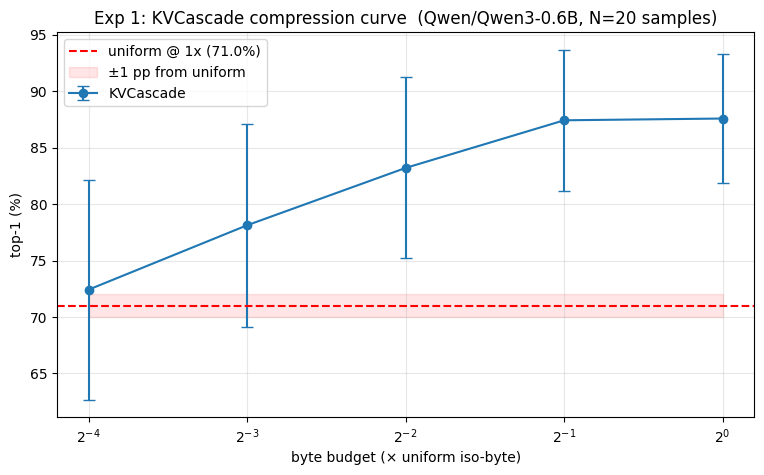

In [13]:
# Plot: top-1 vs byte ratio.
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
xs   = [r for r, _, _, _ in results_exp1]
ys   = [res["top1_mean"] * 100 for _, _, _, res in results_exp1]
errs = [res["top1_std"]  * 100 for _, _, _, res in results_exp1]
ax.errorbar(xs, ys, yerr=errs, marker="o", capsize=4, label="KVCascade")
ax.axhline(res_uni["top1_mean"] * 100, color="red", ls="--",
           label=f"uniform @ 1x ({res_uni['top1_mean']*100:.1f}%)")
ax.fill_between([min(xs), max(xs)],
                (res_uni["top1_mean"] - 0.01) * 100,
                (res_uni["top1_mean"] + 0.01) * 100,
                color="red", alpha=0.1, label="±1 pp from uniform")
ax.set_xscale("log", base=2)
ax.set_xlabel("byte budget (× uniform iso-byte)")
ax.set_ylabel("top-1 (%)")
ax.set_title(f"Exp 1: KVCascade compression curve  ({MODEL_NAME}, N={len(samples)} samples)")
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

## Experiment 2: iso-byte head-to-head

At the same byte budget (= uniform's), compare four configs:

- **Full-fp** (HF default cache, fp16/bf16 KV everywhere): the upper-bound; top-1 = 100% by construction since we computed the reference from this.
- **Uniform TurboQuant** (`k=6/v=2` everywhere).
- **H2O** (no quantization, eviction only, cumulative scoring, `ring_size=0` for strict semantics): same bytes split across fewer fp slots than uniform has quant slots.
- **KVCascade** (recency ring + fp tier + single quant tier): mixed precision, evicts the long tail.

Hypothesis: H2O has only ~¼ as many slots as uniform at iso-byte (since fp slots are ~4× bigger than quant slots in this config), so it should lose despite being lossless within those slots. KVCascade should win because it gets close to uniform's slot count *and* keeps the high-importance ones at fp.

In [14]:
print("Experiment 2: iso-byte head-to-head")
print("=" * 70)

results_exp2 = {}

# Reference upper bound (full-fp HF cache).
fp_baseline_bytes = N_LAYERS * N_KV_HEADS * FP16_BASELINE_PER_LH
results_exp2["full-fp (ref)"] = {
    "label": "full-fp (ref)",
    "bytes": fp_baseline_bytes,
    "top1_mean": 1.0, "top1_std": 0.0,
    "cos_mean":  1.0, "cos_std":  0.0,
    "top1": [1.0] * len(samples), "cos": [1.0] * len(samples),
}

# Uniform reused from Exp 1 if present.
results_exp2["uniform k=6/v=2"] = res_uni

# H2O at iso-byte: how many fp slots fit in uniform's budget?
h2o_cap = int(UNIFORM_BYTES_PER_LH // fp_slot_bytes())
print(f"running H2O @ iso-byte (cache_size={h2o_cap}, ring=0, cumulative)...")
res_h2o = evaluate_config(make_h2o(h2o_cap), install_kvcascade, "h2o")
results_exp2["H2O (ring=0)"] = res_h2o
print(f"  {fmt(res_h2o)}")

# KVCascade at iso-byte: reuse Exp 1's 1.0x entry.
kvc_iso = next((res for r, _, _, res in results_exp1 if r == 1.0), None)
if kvc_iso is None:
    fp_cap = CTX_LEN // 16
    qt_cap = int(kvc_qt_cap_at_budget(UNIFORM_BYTES_PER_LH, 8, fp_cap))
    kvc_iso = evaluate_config(make_kvc(8, fp_cap, qt_cap), install_kvcascade, "kvc")
results_exp2["KVCascade (ring=8 + fp + quant)"] = kvc_iso

# Tabulate.
print()
header = f"{'config':<36}  {'bytes (KiB)':>11}  {'top-1':>22}  {'cos sim':>22}"
print(header); print("-" * len(header))
for name, r in results_exp2.items():
    print(f"{name:<36}  {r['bytes']/1024:>11.0f}  "
          f"{r['top1_mean']*100:>9.1f}% ± {r['top1_std']*100:>5.1f}%   "
          f"{r['cos_mean']:>9.4f} ± {r['cos_std']:>4.4f}")

Experiment 2: iso-byte head-to-head
running H2O @ iso-byte (cache_size=1072, ring=0, cumulative)...
  top1 =  21.6% ±  4.4%  cos = 0.5533 ± 0.0649  bytes =  120064 KiB

config                                bytes (KiB)                   top-1                 cos sim
-------------------------------------------------------------------------------------------------
full-fp (ref)                              458752      100.0% ±   0.0%      1.0000 ± 0.0000
uniform k=6/v=2                            120064       71.0% ±   5.4%      0.9273 ± 0.0173
H2O (ring=0)                               120064       21.6% ±   4.4%      0.5533 ± 0.0649
KVCascade (ring=8 + fp + quant)            120056       87.6% ±   5.7%      0.9880 ± 0.0063


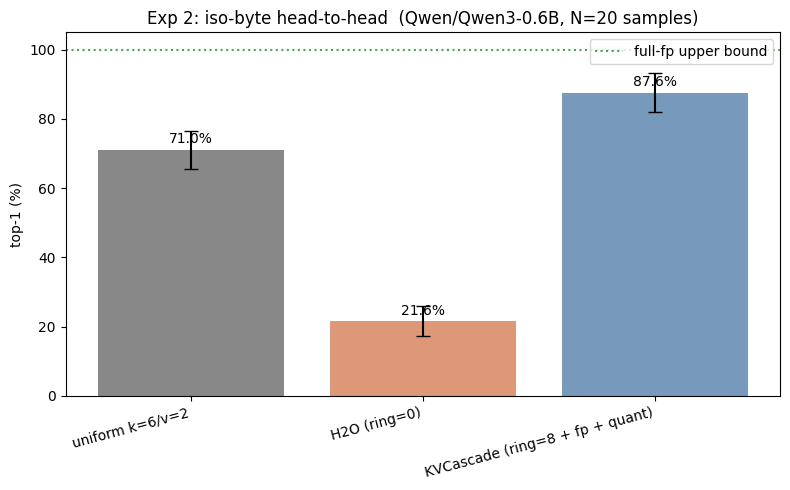

In [15]:
# Bar plot for visual comparison (excluding the ref by-construction 100%).
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_names = [n for n in results_exp2 if "ref" not in n]
top1s = [results_exp2[n]["top1_mean"] * 100 for n in plot_names]
errs  = [results_exp2[n]["top1_std"]  * 100 for n in plot_names]
bars = ax.bar(plot_names, top1s, yerr=errs, capsize=5, color=["#888", "#d97", "#79b"])
ax.axhline(100, color="green", ls=":", alpha=0.7, label="full-fp upper bound")
ax.set_ylabel("top-1 (%)"); ax.set_ylim(0, 105)
ax.set_title(f"Exp 2: iso-byte head-to-head  ({MODEL_NAME}, N={len(samples)} samples)")
ax.legend(); plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, top1s):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

## Experiment 3: split sweep at fixed budget

Fix the byte budget at uniform's iso-byte and ring at 8. Sweep `fp_capacity` from 0 (pure quant) up to a regime where the fp tier eats most of the budget. For each, the quant capacity is set so total bytes match the target.

The trade-off: more fp slots = better precision per slot, fewer total slots; more quant slots = noisier scoring on the long tail, but more tokens retained. The sweet spot tells you where the bytes are best spent.

In [17]:
print("Experiment 3: split sweep at fixed budget")
print("=" * 70)

# FP_CAPACITIES = [0, 32, 64, 128, 256, 512, 1024, 2048, 3072]
FP_CAPACITIES = [1056]
RING_SIZE = 8

results_exp3 = []
for fp_cap in FP_CAPACITIES:
    qt_cap = int(kvc_qt_cap_at_budget(UNIFORM_BYTES_PER_LH, RING_SIZE, fp_cap))
    if qt_cap <= 0 and fp_cap > 0:
        print(f"skipping fp_cap={fp_cap}: budget exhausted by fp tier (qt_cap=0)")
        continue
    label = f"ring={RING_SIZE}, fp={fp_cap:>4}, qt={qt_cap:>4}"
    print(f"running {label}")
    res = evaluate_config(make_kvc(RING_SIZE, fp_cap, qt_cap), install_kvcascade, label)
    results_exp3.append((fp_cap, qt_cap, res))
    print(f"  {fmt(res)}")

Experiment 3: split sweep at fixed budget
running ring=8, fp=1056, qt=  30
  top1 =  88.8% ±  6.8%  cos = 0.9853 ± 0.0143  bytes =  120047 KiB


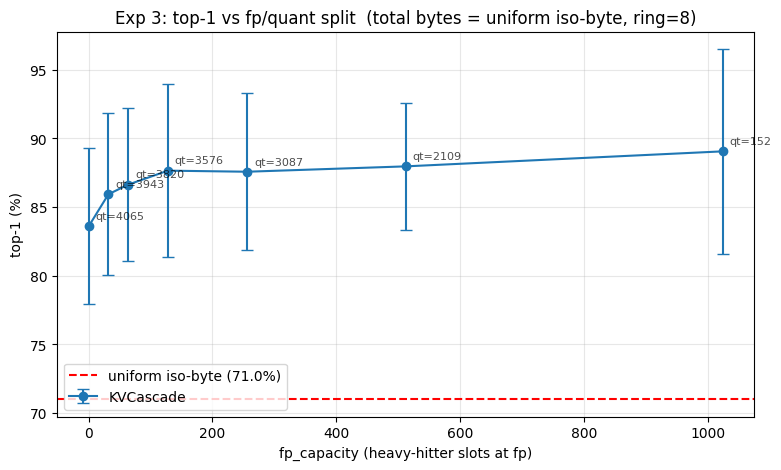


Best split: fp=1024, qt=152 → top1 =  89.1% ±  7.5%  cos = 0.9857 ± 0.0139  bytes =  120040 KiB


In [17]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
xs    = [fp for fp, _, _ in results_exp3]
ys    = [res["top1_mean"] * 100 for _, _, res in results_exp3]
errs  = [res["top1_std"]  * 100 for _, _, res in results_exp3]
qt_at = [qt for _, qt, _ in results_exp3]

ax.errorbar(xs, ys, yerr=errs, marker="o", capsize=4, label="KVCascade")
ax.axhline(res_uni["top1_mean"] * 100, color="red", ls="--",
           label=f"uniform iso-byte ({res_uni['top1_mean']*100:.1f}%)")
for fp, qt, res in results_exp3:
    ax.annotate(f"qt={qt}", (fp, res["top1_mean"] * 100),
                textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.7)

ax.set_xlabel("fp_capacity (heavy-hitter slots at fp)")
ax.set_ylabel("top-1 (%)")
ax.set_title(f"Exp 3: top-1 vs fp/quant split  (total bytes = uniform iso-byte, ring={RING_SIZE})")
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

# Best split per the sweep.
best_fp, best_qt, best_res = max(results_exp3, key=lambda x: x[2]["top1_mean"])
print(f"\nBest split: fp={best_fp}, qt={best_qt} → {fmt(best_res)}")